In [61]:
# Necessay imports
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
# loading the data
data=pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

In [63]:
# checking number of rows and columns
data.shape

(5268, 13)

In [64]:
# more details on the dataset
data.info

<bound method DataFrame.info of             Date   Time                                           Location  \
0     09/17/1908  17:18                                Fort Myer, Virginia   
1     07/12/1912  06:30                            AtlantiCity, New Jersey   
2     08/06/1913    NaN                 Victoria, British Columbia, Canada   
3     09/09/1913  18:30                                 Over the North Sea   
4     10/17/1913  10:30                         Near Johannisthal, Germany   
...          ...    ...                                                ...   
5263  05/20/2009  06:30                             Near Madiun, Indonesia   
5264  05/26/2009    NaN                  Near Isiro, DemocratiRepubliCongo   
5265  06/01/2009  00:15  AtlantiOcean, 570 miles northeast of Natal, Br...   
5266  06/07/2009  08:30       Near Port Hope Simpson, Newfoundland, Canada   
5267  06/08/2009    NaN                  State of Arunachal Pradesh, India   

                             Op

In [65]:
# displaying last 75 rows 
data.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [66]:
data.isnull().sum()

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64

So we came agreed that columns with less than 5% missing values had those rows dropped. Columns with 5% or more missing values were filled with “Unknown” (or a suitable placeholder) to preserve the remaining data.. We chose not to impute so as to maintain prevent bias in the future.

Dropped: Location, Operator, Type, Aboard, Fatalities, Ground

Filled with suitable placeholder: Time, Flight, Route, Registration, cn/In, Summary

In [67]:
# creating fatality_locations dataframe 
fatality_locations = data[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

In [68]:
# checking the date with the highest fatalities 
max_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
max_row['Date']

'03/27/1977'

In [69]:
# Comparing the number of passengers aboard to the number of fatalities per crash.
fatality_locations['Survivors'] = fatality_locations['Aboard'] - fatality_locations['Fatalities']

# Crashes with zero fatalities
zero_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print("Number of crashes with no fatalities:", len(zero_fatalities))

Number of crashes with no fatalities: 58


In [70]:
# splitting location into region and State 
fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)

In [71]:
#Order the dataframe by the number of fatalities from highest to lowest and select the first 100
top100 = fatality_locations.sort_values('Fatalities', ascending=False).head(100)
top100

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,38.0,Busan,South Korea
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,75.0,Irkutsk,Russia
1433,06/30/1956,"Grand Canyon, Arizona",128.0,128.0,0.0,Grand Canyon,Arizona
3970,10/02/1990,"Guangzhou, China",226.0,128.0,98.0,Guangzhou,China


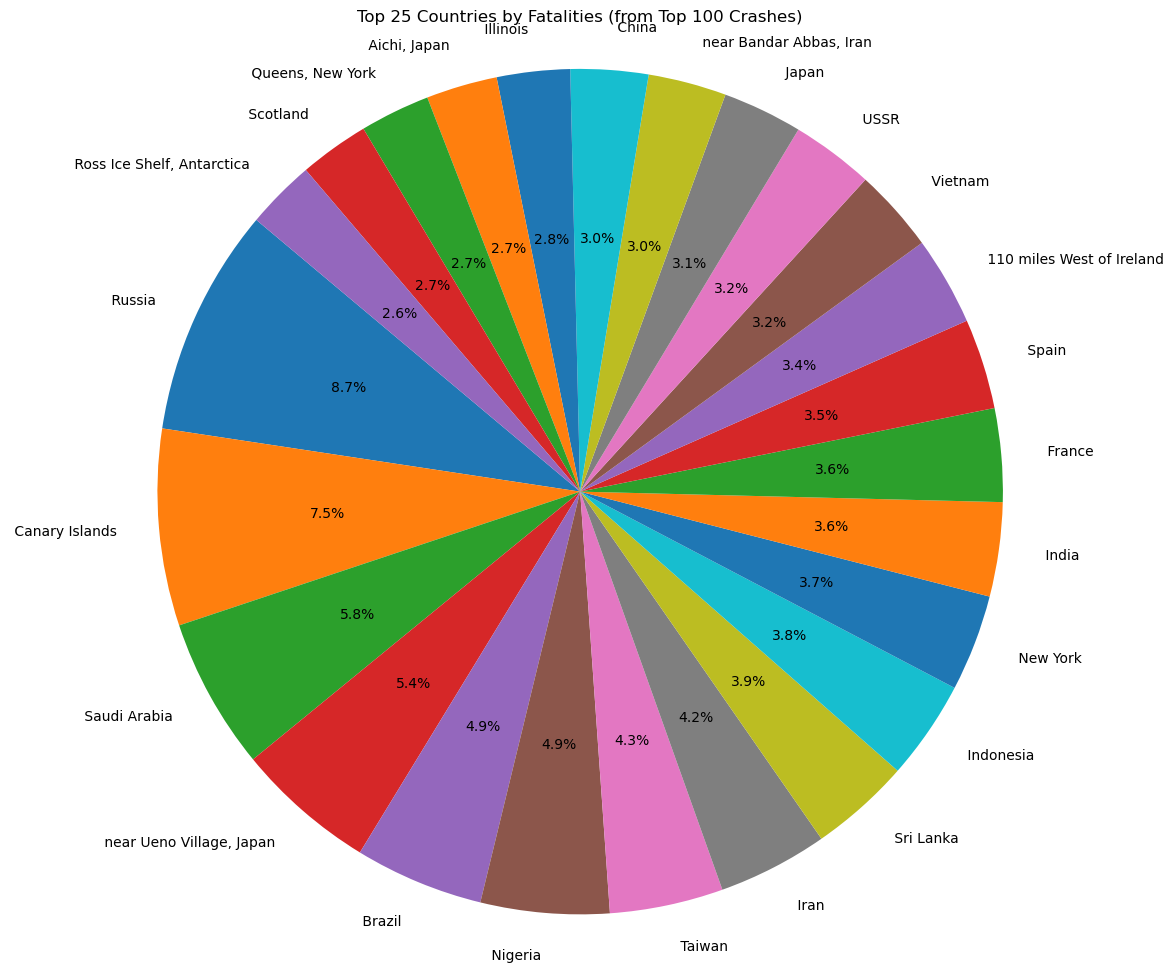

In [72]:
top25_countries = (
    top100.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(12, 12))
plt.pie(
    top25_countries,
    labels=top25_countries.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Top 25 Countries by Fatalities (from Top 100 Crashes)')
plt.axis('equal')
plt.show()